In [35]:
!pip install PyTDC==0.4.17 --quiet
!pip install "numpy<2"
!pip install rdkit

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from tdc.single_pred import HTS, ADME
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
from rdkit import DataStructs

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    roc_auc_score, average_precision_score, balanced_accuracy_score,
    mean_absolute_error, r2_score
)

In [3]:
# Download the data for classification (HTS) and regression (ADME)
HIV_data = HTS(name = 'HIV') #https://tdcommons.ai/single_pred_tasks/hts/?utm_source#hiv:~:text=BY%204.0.-,HIV,benchmark%20for%20molecular%20machine%20learning.%E2%80%9D%20Chemical%20science%209.2%20(2018)%3A%20513%2D530.,-Dataset%20License%3A

HIV_df = HIV_data.get_data()

print(f"Shape of HIV data: {HIV_df.shape}")

display(HIV_df.head())
# Y in HIV (classification is a regression label: )

Found local copy...
Loading...
Done!


Shape of HIV data: (41127, 3)


,Drug_ID,Drug,Y
0,Drug 0,CCC1=[O+][Cu-3]2([O+]=C(CC)C1)[O+]=C(CC)CC(CC)...,0
1,Drug 1,C(=Cc1ccccc1)C1=[O+][Cu-3]2([O+]=C(C=Cc3ccccc3...,0
2,Drug 2,CC(=O)N1c2ccccc2Sc2c1ccc1ccccc21,0
3,Drug 3,Nc1ccc(C=Cc2ccc(N)cc2S(=O)(=O)O)c(S(=O)(=O)O)c1,0
4,Drug 4,O=S(=O)(O)CCS(=O)(=O)O,0


In [4]:
# Identify the files and label the columsn
def infer_columns(df):
    smiles_col = None
    label_col = None

    for c in df.columns:
        if c.lower() in ["drug", "smiles", "molecule"]:
            smiles_col = c
        if c.lower() in ["y", "label", "target"]:
            label_col = c

    return smiles_col, label_col

hiv_smiles_col, hiv_label_col = infer_columns(HIV_df)

print("HIV:", hiv_smiles_col, hiv_label_col)

HIV: Drug Y


In [5]:
# Check SMILES with RDKit
def parse_smiles(smiles):
    if pd.isna(smiles):
        return None
    try:
        return Chem.MolFromSmiles(smiles)
    except Exception:
        return None

hiv_mols = HIV_df[hiv_smiles_col].apply(parse_smiles)

print("Valid HIV molecules:", hiv_mols.notna().sum(), "/", len(hiv_mols))

hiv_invalid = HIV_df.loc[hiv_mols.isna(), [hiv_smiles_col, hiv_label_col]].head()

display(hiv_invalid)

[19:05:03] WARNING: not removing hydrogen atom without neighbors
[19:05:03] WARNING: not removing hydrogen atom without neighbors


Valid HIV molecules: 41127 / 41127


,Drug,Y


In [6]:
#Generate fingerprints:
def morgan_fp_from_mol(mol, radius=2, n_bits=2048): # 2048 column-long fingerprint embeddings
    if mol is None:
        return None
    # https://www.rdkit.org/docs/source/rdkit.Chem.rdMolDescriptors.html#:~:text=rdkit.Chem.rdMolDescriptors.GetMorganFingerprintAsBitVect,api%3A%3Aobject%3DNone%20%5B%2Cbool%3DFalse%5D%5D%5D%5D%5D%5D%5D%5D)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    # https://www.rdkit.org/docs/cppapi/namespaceRDKit_1_1MorganFingerprints.html although MorganFingerprintAsBitVect might be deprecated
    arr = np.zeros((n_bits,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr
# https://rdkit.org/docs/GettingStartedInPython.html

# extract the dataframe matrices abd get X, y, clean_df matrices for analyses
def featurize_dataframe(df, smiles_col, label_col, n_bits=2048):
    mols = df[smiles_col].apply(parse_smiles)
    fps = mols.apply(lambda m: morgan_fp_from_mol(m, n_bits=n_bits))

    mask = fps.notna() & df[label_col].notna()
    X = np.vstack(fps[mask].values)
    y = df.loc[mask, label_col].values
    clean_df = df.loc[mask].copy()

    return X, y, clean_df

X_hiv, y_hiv, hiv_clean = featurize_dataframe(HIV_df, hiv_smiles_col, hiv_label_col)
print("HIV fingerprint matrix:", X_hiv.shape, "labels:", y_hiv.shape)

[19:05:21] WARNING: not removing hydrogen atom without neighbors
[19:05:21] WARNING: not removing hydrogen atom without neighbors


HIV fingerprint matrix: (41127, 2048) labels: (41127,)


In [ ]:
# Lets train Random Forest on the HIV data and evaluate with cross validation
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# we use roc_auc as scoring metric because its binary classification
# and we want to evaluate the model's ability to rank positive vs negative examples
# prc_auc = area under PRC (Precision vs Recall rate curve)
rf_scores = cross_val_score(rf_model, X_hiv, y_hiv, cv=cv, scoring='average_precision')
print("Random Forest AUC-PR scores:", rf_scores)

Random Forest AUC-PR scores: [0.4946858  0.44704462 0.52047637 0.44458765 0.4589985 ]


In [7]:
# Lets do batch passive learning
# active learning
from sklearn.model_selection import cross_validate
from sklearn.pipeline import make_pipeline

def passive(X, y, start_fraction, stop_fraction, size_batch, seed):

    ###### Get random 5 (5%) of the labeled data to start with #######
    rand_num_generator = np.random.default_rng(seed) #creates a random number generator with seed
    n = len(y) #number of labeled data points
    permutation_of_indices = rand_num_generator.permutation(n) #random order of indices from 0 to n-1
    starting_obs = int(start_fraction * n) #get number of starting obsvervations
    ending_obs = int(stop_fraction * n) #get number of ending observations
    observed_indices = permutation_of_indices[0:starting_obs].tolist() #get the indices of the starting observations
    unobserved_indices = permutation_of_indices[starting_obs:].tolist() #get the indices of the remaining observations

    ###### Define SVM Model & Stratified KFold #######
    model = make_pipeline(
        RandomForestClassifier(n_estimators=100, random_state=42)
    )
    ##### Initialize variables to store results #######
    total_points_to_add = ending_obs - starting_obs
    if total_points_to_add % size_batch == 0:
        num_rounds = total_points_to_add // size_batch
    else:
        num_rounds = total_points_to_add // size_batch + 1  # we add size_batch points in each round, plus one for remainder points

    unobserved_accuracy = []

    ###### Train model and evaluate accuracy in each round #######
    for i in range(num_rounds+1):
        if len(unobserved_indices) == 0:
            break
        X_obs = X[observed_indices]
        y_obs = y[observed_indices]

        #train another model on full observed indices
        X_unobs = X[unobserved_indices]
        y_unobs = y[unobserved_indices]
        X_obs = X[observed_indices]
        y_obs = y[observed_indices]
        model.fit(X_obs, y_obs)
        preds = model.predict(X_unobs)
        unobs_score = average_precision_score(y_unobs, preds)
        unobserved_accuracy.append(unobs_score)

        # add size_batch unobserved points randomly to observed indices
        if i < num_rounds:
            points_to_add = min(size_batch, len(unobserved_indices))
            new_observed_indices = unobserved_indices[:points_to_add]
            observed_indices.extend(new_observed_indices)
            unobserved_indices = unobserved_indices[points_to_add:]

    return np.array(unobserved_accuracy)

In [8]:
# Lets do batch active learning
# active learning
from sklearn.model_selection import cross_validate
from sklearn.pipeline import make_pipeline

def active_uncertainty(X, y, start_fraction, stop_fraction, size_batch, seed):

    ###### Get random 5 (5%) of the labeled data to start with #######
    rand_num_generator = np.random.default_rng(seed) #creates a random number generator with seed
    n = len(y) #number of labeled data points
    permutation_of_indices = rand_num_generator.permutation(n) #random order of indices from 0 to n-1
    starting_obs = int(start_fraction * n) #get number of starting obsvervations
    ending_obs = int(stop_fraction * n) #get number of ending observations
    observed_indices = permutation_of_indices[0:starting_obs].tolist() #get the indices of the starting observations
    unobserved_indices = permutation_of_indices[starting_obs:].tolist() #get the indices of the remaining observations

    ###### Define SVM Model & Stratified KFold #######
    model = make_pipeline(
        RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    )
    ##### Initialize variables to store results #######
    total_points_to_add = ending_obs - starting_obs
    if total_points_to_add % size_batch == 0:
        num_rounds = total_points_to_add // size_batch
    else:
        num_rounds = total_points_to_add // size_batch + 1  # we add size_batch points in each round, plus one for remainder points

    unobserved_accuracy = []

    ###### Train model and evaluate accuracy in each round #######
    for i in range(num_rounds+1):
        if len(unobserved_indices) == 0:
            break
        X_obs = X[observed_indices]
        y_obs = y[observed_indices]

        #train another model on full observed indices
        X_unobs = X[unobserved_indices]
        y_unobs = y[unobserved_indices]
        X_obs = X[observed_indices]
        y_obs = y[observed_indices]
        model.fit(X_obs, y_obs)
        probs = model.predict_proba(X_unobs)[:, 1]  # ✅ probability of positive class
        unobs_score = average_precision_score(y_unobs, probs)
        unobserved_accuracy.append(unobs_score)

        # add size_batch unobserved points with highest uncertainty (most disagreement among trees in the random forest)
        if i < num_rounds:
            probs = model.predict_proba(X_unobs)
            entropy = -np.sum(probs * np.log(probs + 1e-10), axis=1) # add small value to avoid log(0)
            uncertain_indices = np.argsort(entropy)[-size_batch:] # get indices of top size_batch most uncertain points
            new_observed_indices = [unobserved_indices[idx] for idx in uncertain_indices]
            observed_indices.extend(new_observed_indices) # add these to observed indices
            unobserved_indices = [idx for idx in unobserved_indices if idx not in new_observed_indices] # remove these from unobserved indices

        if i == num_rounds:
            points_to_add = ending_obs - len(observed_indices)
            if points_to_add > 0:
                probs = model.predict_proba(X_unobs)
                entropy = -np.sum(probs * np.log(probs + 1e-10), axis=1)
                uncertain_indices = np.argsort(entropy)[-points_to_add:]
                new_observed_indices = [unobserved_indices[idx] for idx in uncertain_indices]
                observed_indices.extend(new_observed_indices)
                unobserved_indices = [idx for idx in unobserved_indices if idx not in new_observed_indices]

    return np.array(unobserved_accuracy)


In [9]:
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score
import numpy as np

def active_uncertainty_fixed_held_test(X, y, start_fraction, stop_fraction, size_batch, seed):

    ###### Split off a fixed held-out test set (stratified) #######
    X_pool, X_test, y_pool, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )

    ###### Get random start_fraction of the pool to start with #######
    rand_num_generator = np.random.default_rng(seed)
    n = len(y_pool)
    permutation_of_indices = rand_num_generator.permutation(n)
    starting_obs = int(start_fraction * n)
    ending_obs = int(stop_fraction * n)
    observed_indices = permutation_of_indices[0:starting_obs].tolist()
    unobserved_indices = permutation_of_indices[starting_obs:].tolist()

    ###### Define Model #######
    model = make_pipeline(
        RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    )

    ###### Compute number of rounds #######
    total_points_to_add = ending_obs - starting_obs
    if total_points_to_add % size_batch == 0:
        num_rounds = total_points_to_add // size_batch
    else:
        num_rounds = total_points_to_add // size_batch + 1

    unobserved_auprc = []  # AUPRC on remaining unobserved pool (will go down - expected)
    test_auprc = []        # AUPRC on fixed held-out test set (should go up)

    ###### Train model and evaluate in each round #######
    for i in range(num_rounds + 1):
        if len(unobserved_indices) == 0:
            break

        X_obs   = X_pool[observed_indices]
        y_obs   = y_pool[observed_indices]
        X_unobs = X_pool[unobserved_indices]
        y_unobs = y_pool[unobserved_indices]

        model.fit(X_obs, y_obs)

        # Score on unobserved pool
        unobs_probs = model.predict_proba(X_unobs)[:, 1]
        unobserved_auprc.append(average_precision_score(y_unobs, unobs_probs))

        # Score on fixed test set
        test_probs = model.predict_proba(X_test)[:, 1]
        test_auprc.append(average_precision_score(y_test, test_probs))

        # Select next batch via uncertainty sampling
        if i < num_rounds:
            probs = model.predict_proba(X_unobs)
            entropy = -np.sum(probs * np.log(probs + 1e-10), axis=1)
            uncertain_indices = np.argsort(entropy)[-size_batch:]
            new_observed = [unobserved_indices[idx] for idx in uncertain_indices]
            observed_indices.extend(new_observed)
            unobserved_indices = [idx for idx in unobserved_indices if idx not in new_observed]

        elif i == num_rounds:
            points_to_add = ending_obs - len(observed_indices)
            if points_to_add > 0:
                probs = model.predict_proba(X_unobs)
                entropy = -np.sum(probs * np.log(probs + 1e-10), axis=1)
                uncertain_indices = np.argsort(entropy)[-points_to_add:]
                new_observed = [unobserved_indices[idx] for idx in uncertain_indices]
                observed_indices.extend(new_observed)
                unobserved_indices = [idx for idx in unobserved_indices if idx not in new_observed]

    return np.array(unobserved_auprc), np.array(test_auprc)

### Testing Various Batch Sizes

In [ ]:
#set seed

def run_one_seed_active_learning(seed, X, y, size_batch):
    unobserved_auprc, test_auprc = active_uncertainty_fixed_held_test(
        X,
        y,
        start_fraction=0.2,
        stop_fraction=0.5,
        seed=seed,
        size_batch=size_batch
    )
    print(f"Seed {seed} Batch Size {size_batch} - Unobserved AUPRC: {unobserved_auprc} - Test AUPRC: {test_auprc}")
    return unobserved_auprc, test_auprc

def run_one_seed_passive_learning(seed, X, y, size_batch):
    unobserved_accuracy = passive(
        X,
        y,
        start_fraction=0.2,
        stop_fraction=0.5,
        seed=seed,
        size_batch=size_batch
    )
    print(f"Seed {seed} Batch Size {size_batch} - Unobserved Accuracy: {unobserved_accuracy}")
    return unobserved_accuracy

In [ ]:
#active learning greedy batch selection
#active learning greedy batch selection
# from sklearn.calibration import Parallel, delayed


# all_unobserved_accuracies = []
# all_unobserved_stds = []

# X = X_hiv
# y = y_hiv   # labels
# import os
# n_cpus = os.cpu_count()
# print(f"Available CPUs: {n_cpus}")
# seeds = [123, 456, 789] # !!!!!!!!!!!!! Add 9 more seeds
# #Repeat active learning for different batch sizes and seeds to see which batc size performs best on average across seeds
# results_active_uncertainty_batch250 = Parallel(n_jobs=n_cpus, prefer="processes", verbose=10)(delayed(run_one_seed_active_learning)(seed, X, y, size_batch=250) for seed in seeds)
# print("Finished Batch 250!")
# results_active_uncertainty_batch500 = Parallel(n_jobs=n_cpus, prefer="processes", verbose=10)(delayed(run_one_seed_active_learning)(seed, X, y, size_batch=500) for seed in seeds)
# print("Finished Batch 500!")
# results_active_uncertainty_batch1000 = Parallel(n_jobs=n_cpus, prefer="processes", verbose=10)(delayed(run_one_seed_active_learning)(seed, X, y, size_batch=1000) for seed in seeds)
# print("Finished Batch 1000!")
# results_active_uncertainty_batch2500 = Parallel(n_jobs=n_cpus, prefer="processes", verbose=10)(delayed(run_one_seed_active_learning)(seed, X, y, size_batch=2500) for seed in seeds)
# print("Finished Batch 2500!")
# results_active_uncertainty_batch5000 = Parallel(n_jobs=n_cpus, prefer="processes", verbose=10)(delayed(run_one_seed_active_learning)(seed, X, y, size_batch=5000) for seed in seeds)
# print("Finished Batch 5000!")
# all_unobserved_accuracies_active_uncertainty_batch250 = [r[0] for r in results_active_uncertainty_batch250]
# all_unobserved_accuracies_active_uncertainty_batch500 = [r[0] for r in results_active_uncertainty_batch500]
# all_unobserved_accuracies_active_uncertainty_batch1000 = [r[0] for r in results_active_uncertainty_batch1000]
# all_unobserved_accuracies_active_uncertainty_batch2500 = [r[0] for r in results_active_uncertainty_batch2500]
# all_unobserved_accuracies_active_uncertainty_batch5000 = [r[0] for r in results_active_uncertainty_batch5000]

from sklearn.calibration import Parallel, delayed
import os

X = X_hiv
y = y_hiv

n_cpus = os.cpu_count()
print(f"Available CPUs: {n_cpus}")
seeds = [123, 456, 789]

# Run active learning for each batch size
results_active_uncertainty_batch250 = Parallel(n_jobs=n_cpus, prefer="processes", verbose=10)(delayed(run_one_seed_active_learning)(seed, X, y, size_batch=250) for seed in seeds)
print("Finished Batch 250!")
results_active_uncertainty_batch500 = Parallel(n_jobs=n_cpus, prefer="processes", verbose=10)(delayed(run_one_seed_active_learning)(seed, X, y, size_batch=500) for seed in seeds)
print("Finished Batch 500!")
results_active_uncertainty_batch1000 = Parallel(n_jobs=n_cpus, prefer="processes", verbose=10)(delayed(run_one_seed_active_learning)(seed, X, y, size_batch=1000) for seed in seeds)
print("Finished Batch 1000!")
results_active_uncertainty_batch2500 = Parallel(n_jobs=n_cpus, prefer="processes", verbose=10)(delayed(run_one_seed_active_learning)(seed, X, y, size_batch=2500) for seed in seeds)
print("Finished Batch 2500!")
results_active_uncertainty_batch5000 = Parallel(n_jobs=n_cpus, prefer="processes", verbose=10)(delayed(run_one_seed_active_learning)(seed, X, y, size_batch=5000) for seed in seeds)
print("Finished Batch 5000!")

# Unpack unobserved pool AUPRC (r[0]) and test AUPRC (r[1]) for each batch size
all_unobserved_auprc_batch250  = [r[0] for r in results_active_uncertainty_batch250]
all_test_auprc_batch250        = [r[1] for r in results_active_uncertainty_batch250]

all_unobserved_auprc_batch500  = [r[0] for r in results_active_uncertainty_batch500]
all_test_auprc_batch500        = [r[1] for r in results_active_uncertainty_batch500]

all_unobserved_auprc_batch1000 = [r[0] for r in results_active_uncertainty_batch1000]
all_test_auprc_batch1000       = [r[1] for r in results_active_uncertainty_batch1000]

all_unobserved_auprc_batch2500 = [r[0] for r in results_active_uncertainty_batch2500]
all_test_auprc_batch2500       = [r[1] for r in results_active_uncertainty_batch2500]

all_unobserved_auprc_batch5000 = [r[0] for r in results_active_uncertainty_batch5000]
all_test_auprc_batch5000       = [r[1] for r in results_active_uncertainty_batch5000]

Available CPUs: 2


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


Finished Batch 250!


[Parallel(n_jobs=2)]: Done   3 out of   3 | elapsed: 35.3min finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


Finished Batch 500!


[Parallel(n_jobs=2)]: Done   3 out of   3 | elapsed: 17.5min finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   3 out of   3 | elapsed:  9.1min finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


Finished Batch 1000!


[Parallel(n_jobs=2)]: Done   3 out of   3 | elapsed:  4.2min finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


Finished Batch 2500!
Finished Batch 5000!


[Parallel(n_jobs=2)]: Done   3 out of   3 | elapsed:  2.6min finished


In [ ]:
import numpy as np

def compute_mean_std_across_seeds(all_accuracies_per_seed):
    """
    Computes mean and std across seeds for each iteration step.

    all_accuracies_per_seed: list of arrays, one per seed.
                             Each array has shape (n_iterations,)
    Returns:
        mean_acc: array of shape (n_iterations,)
        std_acc:  array of shape (n_iterations,)
    """
    # Stack into shape (n_seeds, n_iterations)
    stacked = np.array(all_accuracies_per_seed)
    mean_acc = np.mean(stacked, axis=0)
    std_acc  = np.std(stacked, axis=0)
    return mean_acc, std_acc

# Compute mean/std across seeds for both metrics
batch_results_unobs = {
    250:  dict(zip(["mean", "std"], compute_mean_std_across_seeds(all_unobserved_auprc_batch250))),
    500:  dict(zip(["mean", "std"], compute_mean_std_across_seeds(all_unobserved_auprc_batch500))),
    1000: dict(zip(["mean", "std"], compute_mean_std_across_seeds(all_unobserved_auprc_batch1000))),
    2500: dict(zip(["mean", "std"], compute_mean_std_across_seeds(all_unobserved_auprc_batch2500))),
    5000: dict(zip(["mean", "std"], compute_mean_std_across_seeds(all_unobserved_auprc_batch5000))),
}

batch_results_test = {
    250:  dict(zip(["mean", "std"], compute_mean_std_across_seeds(all_test_auprc_batch250))),
    500:  dict(zip(["mean", "std"], compute_mean_std_across_seeds(all_test_auprc_batch500))),
    1000: dict(zip(["mean", "std"], compute_mean_std_across_seeds(all_test_auprc_batch1000))),
    2500: dict(zip(["mean", "std"], compute_mean_std_across_seeds(all_test_auprc_batch2500))),
    5000: dict(zip(["mean", "std"], compute_mean_std_across_seeds(all_test_auprc_batch5000))),
}

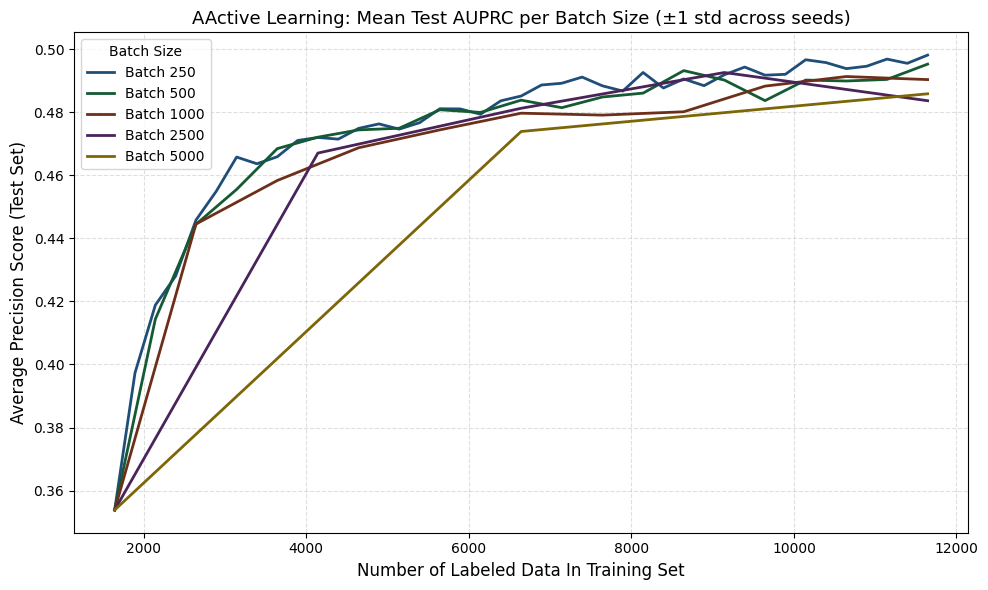

In [ ]:
n_pool = int(0.8 * len(y))  # since you split off 20% for test
starting_obs = int(0.05 * n_pool)

x_labeled = {}
for bs in [250, 500, 1000, 2500, 5000]:
    n_iterations = len(batch_results_test[bs]["mean"])
    labeled = starting_obs + bs * np.arange(n_iterations)
    labeled = np.minimum(labeled, n_pool)  # cap at pool size
    x_labeled[bs] = labeled

import matplotlib.pyplot as plt
import numpy as np

# Define a dark color for each batch size
batch_colors = {
    250:  "#1f4e79",  # dark blue
    500:  "#145a32",  # dark green
    1000: "#6e2f1a",  # dark brown/red
    2500: "#4a235a",  # dark purple
    5000: "#7d6608",  # dark gold/olive
}

fig, ax = plt.subplots(figsize=(10, 6))

for bs, res in batch_results_test.items():
    mean = res["mean"]
    std  = res["std"]
    color = batch_colors[bs]
    x = x_labeled[bs]

    ax.plot(x, mean, color=color, linewidth=2, label=f"Batch {bs}")
    #ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.2)

ax.set_xlabel("Number of Labeled Data In Training Set", fontsize=12)
ax.set_ylabel("Average Precision Score (Test Set)", fontsize=12)
ax.set_title("AActive Learning: Mean Test AUPRC per Batch Size (±1 std across seeds)", fontsize=13)
ax.legend(title="Batch Size", fontsize=10)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
#i think we are seeing this because there are fewer true positives in the unobserved data

### Testing Various Starting Fractions

In [11]:
#set seed

def run_one_seed_active_learning(seed, X, y, size_batch, start_fraction):
    unobserved_auprc, test_auprc = active_uncertainty_fixed_held_test(
        X,
        y,
        start_fraction=start_fraction,
        stop_fraction=0.5,
        seed=seed,
        size_batch=size_batch
    )
    print(f"Seed {seed} Batch Size {size_batch} - Unobserved AUPRC: {unobserved_auprc} - Test AUPRC: {test_auprc}")
    return unobserved_auprc, test_auprc

def run_one_seed_passive_learning(seed, X, y, size_batch):
    unobserved_accuracy = passive(
        X,
        y,
        start_fraction=0.2,
        stop_fraction=0.5,
        seed=seed,
        size_batch=size_batch
    )
    print(f"Seed {seed} Batch Size {size_batch} - Unobserved Accuracy: {unobserved_accuracy}")
    return unobserved_accuracy

In [12]:
from sklearn.calibration import Parallel, delayed
import os

X = X_hiv
y = y_hiv

n_cpus = os.cpu_count()
print(f"Available CPUs: {n_cpus}")
seeds = [123, 456, 789]

# Run active learning for each batch size
results_active_uncertainty_stfrac5 = Parallel(n_jobs=n_cpus, prefer="processes", verbose=10)(delayed(run_one_seed_active_learning)(seed, X, y, start_fraction=0.05, size_batch=2500) for seed in seeds)
print("Finished Start Fraction 5%!")
results_active_uncertainty_stfrac10 = Parallel(n_jobs=n_cpus, prefer="processes", verbose=10)(delayed(run_one_seed_active_learning)(seed, X, y, start_fraction=0.1, size_batch=2500) for seed in seeds)
print("Finished Start Fraction 10%!")
results_active_uncertainty_stfrac15 = Parallel(n_jobs=n_cpus, prefer="processes", verbose=10)(delayed(run_one_seed_active_learning)(seed, X, y, start_fraction=0.15, size_batch=2500) for seed in seeds)
print("Finished Start Fraction 15%!")
results_active_uncertainty_stfrac20 = Parallel(n_jobs=n_cpus, prefer="processes", verbose=10)(delayed(run_one_seed_active_learning)(seed, X, y, start_fraction=0.2, size_batch=2500) for seed in seeds)
print("Finished Start Fraction 20%!")
results_active_uncertainty_stfrac25 = Parallel(n_jobs=n_cpus, prefer="processes", verbose=10)(delayed(run_one_seed_active_learning)(seed, X, y, start_fraction=0.25, size_batch=2500) for seed in seeds)
print("Finished Start Fraction 25%!")

# Unpack unobserved pool AUPRC (r[0]) and test AUPRC (r[1]) for each batch size
all_unobserved_auprc_stfrac5  = [r[0] for r in results_active_uncertainty_stfrac5]
all_test_auprc_stfrac5        = [r[1] for r in results_active_uncertainty_stfrac5]

all_unobserved_auprc_stfrac10  = [r[0] for r in results_active_uncertainty_stfrac10]
all_test_auprc_stfrac10        = [r[1] for r in results_active_uncertainty_stfrac10]

all_unobserved_auprc_stfrac15 = [r[0] for r in results_active_uncertainty_stfrac15]
all_test_auprc_stfrac15       = [r[1] for r in results_active_uncertainty_stfrac15]

all_unobserved_auprc_stfrac20 = [r[0] for r in results_active_uncertainty_stfrac20]
all_test_auprc_stfrac20       = [r[1] for r in results_active_uncertainty_stfrac20]

all_unobserved_auprc_stfrac25 = [r[0] for r in results_active_uncertainty_stfrac25]
all_test_auprc_stfrac25       = [r[1] for r in results_active_uncertainty_stfrac25]

Available CPUs: 2


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   3 out of   3 | elapsed:  4.9min finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


Finished Start Fraction 5%!


[Parallel(n_jobs=2)]: Done   3 out of   3 | elapsed:  5.7min finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


Finished Start Fraction 10%!


[Parallel(n_jobs=2)]: Done   3 out of   3 | elapsed:  4.9min finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


Finished Start Fraction 15%!


[Parallel(n_jobs=2)]: Done   3 out of   3 | elapsed:  4.3min finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


Finished Start Fraction 20%!
Finished Start Fraction 25%!


[Parallel(n_jobs=2)]: Done   3 out of   3 | elapsed:  4.9min finished


In [15]:
import numpy as np

def compute_mean_std_across_seeds(all_accuracies_per_seed):
    """
    Computes mean and std across seeds for each iteration step.

    all_accuracies_per_seed: list of arrays, one per seed.
                             Each array has shape (n_iterations,)
    Returns:
        mean_acc: array of shape (n_iterations,)
        std_acc:  array of shape (n_iterations,)
    """
    # Stack into shape (n_seeds, n_iterations)
    stacked = np.array(all_accuracies_per_seed)
    mean_acc = np.mean(stacked, axis=0)
    std_acc  = np.std(stacked, axis=0)
    return mean_acc, std_acc

# Compute mean/std across seeds for both metrics
stfrac_results_unobs = {
    5:  dict(zip(["mean", "std"], compute_mean_std_across_seeds(all_unobserved_auprc_stfrac5))),
    10:  dict(zip(["mean", "std"], compute_mean_std_across_seeds(all_unobserved_auprc_stfrac10))),
    15: dict(zip(["mean", "std"], compute_mean_std_across_seeds(all_unobserved_auprc_stfrac15))),
    20: dict(zip(["mean", "std"], compute_mean_std_across_seeds(all_unobserved_auprc_stfrac20))),
    25: dict(zip(["mean", "std"], compute_mean_std_across_seeds(all_unobserved_auprc_stfrac25))),
}

stfrac_results_test = {
    5:  dict(zip(["mean", "std"], compute_mean_std_across_seeds(all_test_auprc_stfrac5))),
    10:  dict(zip(["mean", "std"], compute_mean_std_across_seeds(all_test_auprc_stfrac10))),
    15: dict(zip(["mean", "std"], compute_mean_std_across_seeds(all_test_auprc_stfrac15))),
    20: dict(zip(["mean", "std"], compute_mean_std_across_seeds(all_test_auprc_stfrac20))),
    25: dict(zip(["mean", "std"], compute_mean_std_across_seeds(all_test_auprc_stfrac25))),
}

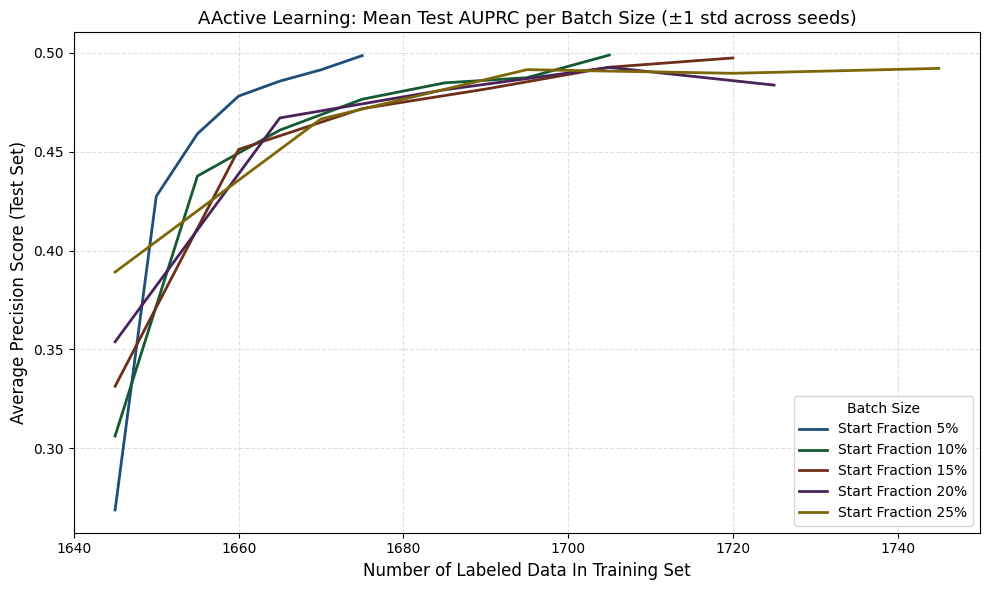

In [ ]:
n_pool = int(0.8 * len(y))  # since you split off 20% for test
x_labeled = {}
for stfrac in [5, 10, 15, 20, 25]:
    starting_obs = int((stfrac / 100) * n_pool)
    n_iterations = len(stfrac_results_test[stfrac]["mean"])
    labeled = starting_obs + 2500 * np.arange(n_iterations)  # batch size is 2500
    labeled = np.minimum(labeled, n_pool)  # cap at pool size
    x_labeled[stfrac] = labeled
import matplotlib.pyplot as plt
import numpy as np

# Define a dark color for each batch size
stfrac_colors = {
    5:  "#1f4e79",  # dark blue
    10:  "#145a32",  # dark green
    15: "#6e2f1a",  # dark brown/red
    20: "#4a235a",  # dark purple
    25: "#7d6608",  # dark gold/olive
}

fig, ax = plt.subplots(figsize=(10, 6))

for bs, res in stfrac_results_test.items():
    mean = res["mean"]
    std  = res["std"]
    color = stfrac_colors[bs]
    x = x_labeled[bs]

    ax.plot(x, mean, color=color, linewidth=2, label=f"Start Fraction {bs}%")
    #ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.2)

ax.set_xlabel("Number of Labeled Data In Training Set", fontsize=12)
ax.set_ylabel("Average Precision Score (Test Set)", fontsize=12)
ax.set_title("AActive Learning: Mean Test AUPRC per Batch Size (±1 std across seeds)", fontsize=13)
ax.legend(title="Batch Size", fontsize=10)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
#i think we are seeing this because there are fewer true positives in the unobserved data